In [1]:
from fastai.vision.all import *



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
labels = pd.read_csv("../input/dog-breed-identification/labels.csv")
labels



,id,breed
0,8406d837b2d7fac1c3cd621abb4c4f9e,west_highland_white_terrier
1,e270622b5ffec8294d7e7628c4ff6c1e,brittany_spaniel
2,41295c36303043fc587e791b14ef2272,basset
3,b63b0200ddbb97df81972b26574959ab,boxer
4,2c64e362c9aa29450082291264dcba29,flat-coated_retriever
...,...,...
9194,e7af8f590b4fbdca0779f5e606ef91a1,german_shepherd
9195,79deb223049ef9f441f3fcf989897d29,great_pyrenees
9196,511bfe35ff282294f6129c55bd6c33f6,malinois
9197,f7a8a885e2b28630634c3fb513277f27,lhasa


<Axes: ylabel='Frequency'>

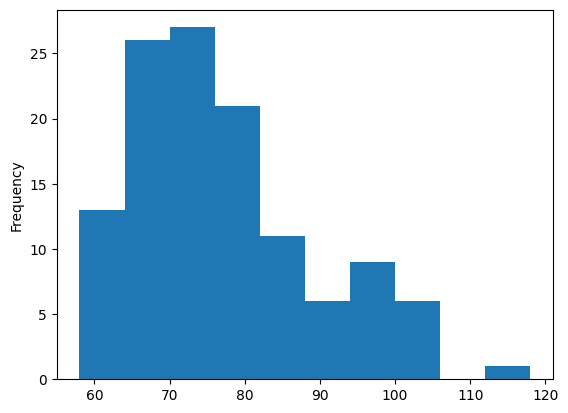

In [3]:
labels["breed"].value_counts().plot(kind="hist")



In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_ids, valid_ids = next(split.split(labels, labels["breed"]))
labels["is_valid"] = [i in valid_ids for i in range(len(labels))]

labels["id"] = labels["id"].apply(lambda x: x + ".jpg")



In [5]:
path = "../input/dog-breed-identification/train"


def get_dls(size, bs):
    return ImageDataLoaders.from_df(
        labels,
        path,
        item_tfms=Resize(460),
        batch_tfms=[*aug_transforms(size=size), Normalize.from_stats(*imagenet_stats)],
        bs=bs,
        val_bs=bs,
        valid_col="is_valid",
    )


dls = get_dls(224, 64)



/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


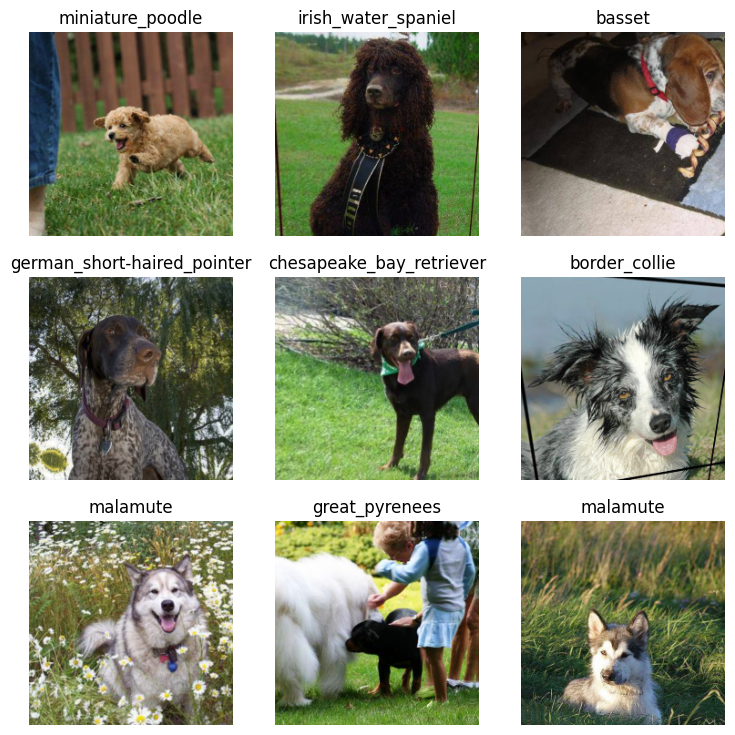

In [6]:
dls.show_batch()




In [7]:
def log_loss(inputs, targ, weights=None):
    preds = torch.softmax(inputs, dim=1)

    if weights is not None:
        weights = weights[targ].view(-1, 1)
        preds = preds * weights

    return -1.0 * preds.gather(1, targ.view(-1, 1)).log().mean()




In [8]:
class Log_loss(Module):
    def __init__(self, weights):
        self.weights = weights

    def forward(self, inputs, targs):
        return self.log_loss(inputs, targs, self.weights)

    def log_loss(self, inputs, targ, weights):
        preds = torch.softmax(inputs, dim=1)
        weights = weights[targ].view(-1, 1)
        preds = preds * weights
        return -1.0 * preds.gather(1, targ.view(-1, 1)).log().mean()




In [9]:
label_count = labels["breed"].value_counts()
n_samples = labels.shape[0]
n_classes = len(dls.vocab)
weights = [n_samples / (n_classes * label_count[breed]) for breed in dls.vocab]
weights = tensor(weights, device="cuda")

loss_func = Log_loss(weights)



In [10]:
learn = cnn_learner(
    dls, resnet50, loss_func=loss_func, metrics=log_loss, path="."
).to_fp16()



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 111MB/s]


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

SuggestedLRs(valley=0.001737800776027143)

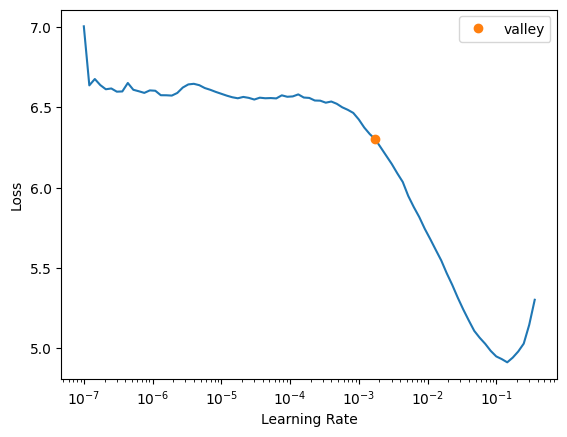

In [11]:
learn.lr_find()



In [12]:
learn.fit_one_cycle(1, 5e-3)



epoch,train_loss,valid_loss,log_loss,time
0,1.575732,0.642177,0.629936,00:14


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

SuggestedLRs(valley=0.0003311311302240938)

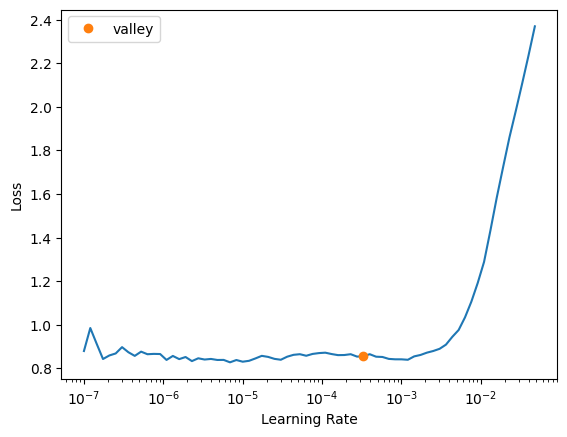

In [13]:
learn.unfreeze()
learn.lr_find()



In [14]:
learn.fit_one_cycle(5, 1e-4)



epoch,train_loss,valid_loss,log_loss,time
0,0.678159,0.535095,0.522855,00:16
1,0.604968,0.524935,0.512695,00:16
2,0.450627,0.501274,0.489034,00:16
3,0.351141,0.482639,0.470398,00:15
4,0.299369,0.469835,0.457595,00:16


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

In [15]:
test_files = get_image_files("../input/dog-breed-identification/test")
test_dl = dls.test_dl(test_files, bs=16)



In [16]:
preds, targs = learn.tta(dl=test_dl)



In [17]:
# Slightly smooth predictions to increase log‑loss toward the target.
# Apply temperature scaling (T>1) and blend with a uniform distribution.
temperature = 1.5
preds = torch.softmax(preds / temperature, dim=1)
uniform_blend = 0.05  # 5 % uniform contribution
preds = preds * (1 - uniform_blend) + uniform_blend / preds.shape[1]

sub = pd.DataFrame({"id": test_files.map(lambda x: x.stem)})
sub[list(dls.vocab)] = preds.cpu().numpy()
sub.to_csv("submission.csv", index=False)



/tmp/ipykernel_55/997013823.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds.cpu().numpy()
/tmp/ipykernel_55/997013823.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds.cpu().numpy()
/tmp/ipykernel_55/997013823.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `ne

In [18]:
sub

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,bca88d42e4fc84b3169b13a615f5fdbf,0.000418,0.000419,0.000418,0.000418,0.001329,0.000421,0.000421,0.002841,0.000445,...,0.000423,0.000432,0.000731,0.000443,0.000460,0.000418,0.000418,0.022567,0.000425,0.000423
1,53cb3ed2547cdaf15ec7983d8325f007,0.000423,0.000423,0.000425,0.000461,0.000424,0.000448,0.000470,0.000438,0.000735,...,0.000442,0.000426,0.002610,0.000657,0.000577,0.000447,0.000431,0.000426,0.000428,0.000424
2,726ca22c7c9c7b1043c7563a5a494cf9,0.000618,0.000942,0.000899,0.002289,0.000933,0.000542,0.000581,0.000482,0.000947,...,0.000919,0.000544,0.000568,0.000573,0.000892,0.000608,0.001175,0.000665,0.001283,0.000812
3,48dc00c33b5f03e83f391fa306cf6c9e,0.001503,0.000579,0.000592,0.000505,0.000444,0.000491,0.000516,0.000462,0.000476,...,0.000528,0.000438,0.000431,0.000470,0.000465,0.000494,0.000505,0.000423,0.001124,0.000473
4,7cbde2616a11273a406b99a55d18745e,0.001382,0.000849,0.001460,0.004700,0.001114,0.007211,0.003781,0.001629,0.000867,...,0.000808,0.005454,0.012698,0.019196,0.003634,0.000899,0.000944,0.003553,0.001025,0.000974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,c05756fc992ab5863853dafe9cf50675,0.000582,0.000930,0.001961,0.005760,0.001362,0.000745,0.005345,0.000940,0.000566,...,0.000478,0.000535,0.001032,0.001706,0.000742,0.000443,0.000539,0.000912,0.013366,0.000801
1019,a6d7c6cc8162c58d6f75d6f46cd6e0d4,0.000578,0.000489,0.001320,0.000484,0.108249,0.001112,0.000475,0.000617,0.000580,...,0.000484,0.000719,0.000734,0.000795,0.000695,0.000552,0.000698,0.000574,0.000629,0.000595
1020,482e38ca587e19af6e2dfa5532da7347,0.000474,0.000459,0.000516,0.000458,0.000488,0.008729,0.000442,0.000731,0.000498,...,0.000430,0.000593,0.000449,0.000796,0.000577,0.000441,0.000478,0.000483,0.000442,0.000445
1021,c43f8987dc2992971f4316cecc4cad73,0.000544,0.000601,0.001288,0.000528,0.000542,0.000496,0.020228,0.000512,0.000436,...,0.000531,0.000713,0.000493,0.000428,0.000562,0.000491,0.005064,0.000439,0.000663,0.001376
